In [1]:
!pip install pymorphy3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 64.5 MB/s eta 0:00:00


In [ ]:
!pip install transformers datasets -q

In [ ]:
import numpy as np
import pandas as pd

from tqdm import tqdm
import time
import re

import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
%matplotlib inline


from wordcloud import WordCloud

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             confusion_matrix,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)


from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

import pymorphy3
from wordcloud import STOPWORDS
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords


import torch
from torch.utils.data import Dataset, DataLoader
from IPython.utils.sysinfo import encoding

from transformers import AutoTokenizer, AutoModelForSequenceClassification

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
data = pd.read_csv('/content/labeled.csv',header=0, names=['text','toxic'])

In [6]:
data['toxic'] = data['toxic'].astype(int)

In [7]:
print(f'Всего строк: {len(data)}')
print(f'Дубликатов по тексту: {data.duplicated(subset="text").sum()}')

data = data.drop_duplicates(subset='text').reset_index(drop=True)
data = data[data['text'].str.strip() != ''].reset_index(drop=True)

print(f'После очистки: {len(data)}')
data['toxic'].value_counts(normalize=True)

Всего строк: 14412
Дубликатов по тексту: 0
После очистки: 14412


,proportion
toxic,
0,0.66514
1,0.33486


In [8]:
print(f'Normal: {data['toxic'].value_counts()[0]}')
print(f'Toxic: {data['toxic'].value_counts()[1]}')
data['toxic'].value_counts(normalize=True) * 100

Normal: 9586
Toxic: 4826


,proportion
toxic,
0,66.514016
1,33.485984


In [9]:
data['len_row'] = data['text'].str.len()
print(data.groupby('toxic')['len_row'].mean())
print('-' * 40)
print(data.groupby('toxic')['len_row'].min())
print('-' * 40)
print(data.groupby('toxic')['len_row'].max())

toxic
0    194.213332
1    141.392665
Name: len_row, dtype: float64
----------------------------------------
toxic
0    21
1    21
Name: len_row, dtype: int64
----------------------------------------
toxic
0    7404
1    5218
Name: len_row, dtype: int64


<Axes: ylabel='Frequency'>

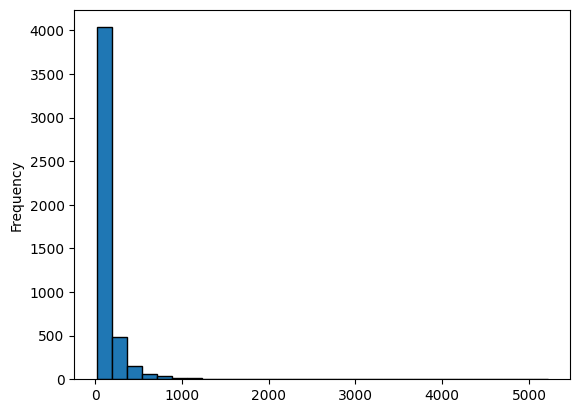

In [ ]:
data[data['toxic'] == 1]['len_row'].plot.hist(bins=30, edgecolor='black')

<Axes: ylabel='Frequency'>

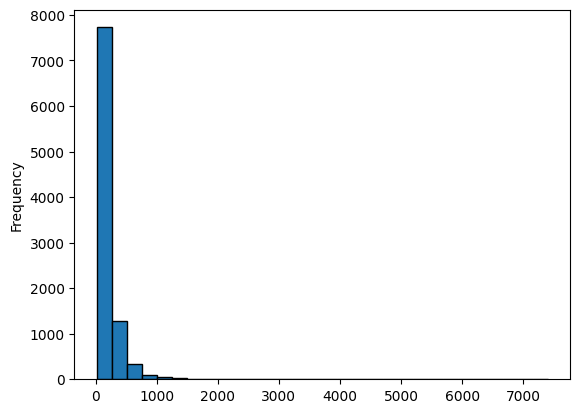

In [ ]:
data[data['toxic'] == 0]['len_row'].plot.hist(bins=30, edgecolor='black')

In [11]:
def norm(texts):

    text = ' '.join(texts.astype(str).tolist())
    text = re.sub(r'[^A-Za-zА-Яа-я\s]', '', text)
    text = text.lower()
    s_words = set(stopwords.words("russian"))
    text = ' '.join([word for word in text.split() if word not in s_words])

    return text
pos_text = norm(data[data['toxic'] == 0]['text'])
neg_text = norm(data[data['toxic'] == 1]['text'])

In [12]:
def gen_word_cloud(text):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title("Word Cloud")
    plt.show()

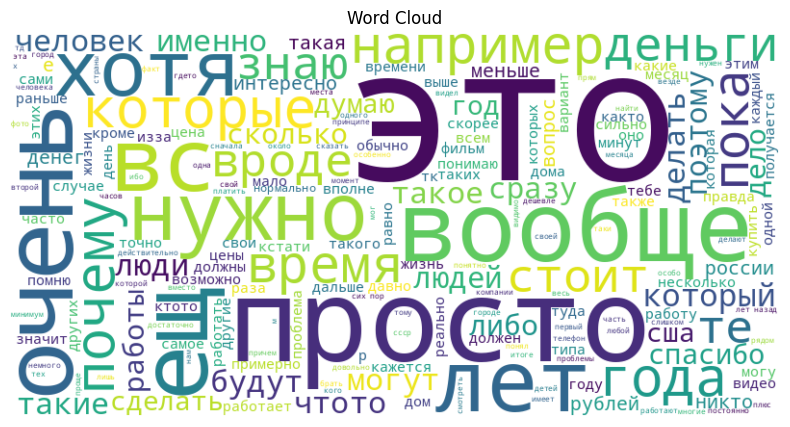

In [ ]:
gen_word_cloud(pos_text)

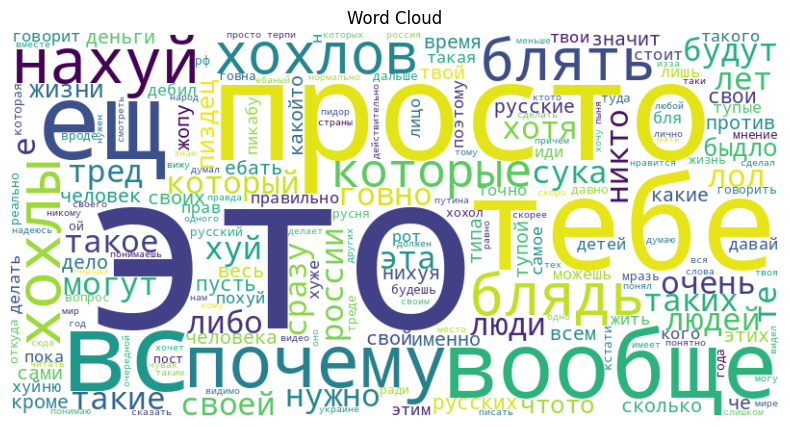

In [ ]:
gen_word_cloud(neg_text)

## Предобработка

In [10]:
morph = pymorphy3.MorphAnalyzer()
s_words = set(stopwords.words("russian"))

In [13]:
def data_cleaning(text):
    text = text.lower()
    text = re.sub(r'[^а-яё\s]', '', text)

    clean_words = [morph.parse(word)[0].normal_form for word in text.split() if word not in s_words]
    return ' '.join(clean_words)

In [14]:
tqdm.pandas()
data['text_clean'] = data['text'].progress_apply(data_cleaning)

100%|██████████| 14412/14412 [00:51<00:00, 277.71it/s]


In [16]:
X = data['text_clean']
y = data['toxic']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15,
                                                    random_state=42,
                                                    stratify=y )
print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Токсичных в train: {y_train.sum()}, в test: {y_test.sum()}")

Train: 12250, Test: 2162
Токсичных в train: 4102, в test: 724


## Baseline

In [29]:
vectorizer = TfidfVectorizer()

In [30]:
lr = LogisticRegression(class_weight='balanced', random_state=42)
pipeline = Pipeline([
    ('tfidf', vectorizer),
    ('clf', lr)
])

param_grid = {

    'tfidf__max_df': [0.75, 1.0],
    'tfidf__ngram_range': [(1, 1), (1, 2)],

    'clf__C': [0.1, 1.0, 10.0],
    'clf__penalty': ['l2'],
    'clf__solver': ['lbfgs']
}


grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("Performing grid search...")
grid_search.fit(X_train, y_train)


Performing grid search...
Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidf', TfidfVectorizer()),
                                       ('clf',
                                        LogisticRegression(class_weight='balanced',
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'clf__C': [0.1, 1.0, 10.0], 'clf__penalty': ['l2'],
                         'clf__solver': ['lbfgs'], 'tfidf__max_df': [0.75, 1.0],
                         'tfidf__ngram_range': [(1, 1), (1, 2)]},
             scoring='f1', verbose=1)

In [31]:
print(f"\nBest Score (F1 Macro): {grid_search.best_score_:.4f}")
print("Best Parameters Found:")
for param_name in sorted(param_grid.keys()):
    print(f"  {param_name}: {grid_search.best_params_[param_name]}")

start_time = time.time()
lr_pred = grid_search.predict(X_test)
end_time = time.time() - start_time

print("\nLogistic Regression")
print(f"Время обучения: {end_time:.2f} s")
print(f"F1-Score: {f1_score(y_test, lr_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, lr_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))


Best Score (F1 Macro): 0.8111
Best Parameters Found:
  clf__C: 1.0
  clf__penalty: l2
  clf__solver: lbfgs
  tfidf__max_df: 0.75
  tfidf__ngram_range: (1, 1)

Logistic Regression
Время обучения: 0.07 s
F1-Score: 0.8175
ROC-AUC: 0.8623

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91      1438
           1       0.82      0.81      0.82       724

    accuracy                           0.88      2162
   macro avg       0.86      0.86      0.86      2162
weighted avg       0.88      0.88      0.88      2162



In [ ]:
num_neg = np.sum(y_train == 0)
num_pos = np.sum(y_train == 1)

ratio = num_neg / num_pos

In [ ]:
xg_boost = XGBClassifier(random_state=42, scale_pos_weight=ratio,)
pipeline = Pipeline([
    ('tfidf', vectorizer),
    ('clf', xg_boost)
])

param_grid = {

    'tfidf__max_df': [0.75, 1.0],
    'tfidf__ngram_range': [(1, 1), (1, 2)],

    "clf__max_depth": [6, 10, 15],
    "clf__n_estimators": [200, 300],
    "clf__min_child_weight": [1, 300, 1000],
    "clf__learning_rate": [0.1, 0.3, 1],
    "clf__gamma": [0, 0.01, 0.1]
}


grid_search = RandomizedSearchCV(
    estimator=pipeline, n_iter=30,
    param_distributions=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

grid_search.fit(X_train, y_train)

Performing grid search...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Score (F1 Macro): 0.7403
Best Parameters Found:
  clf__gamma: 0.01
  clf__learning_rate: 0.3
  clf__max_depth: 15
  clf__min_child_weight: 1
  clf__n_estimators: 300
  tfidf__max_df: 0.75
  tfidf__ngram_range: (1, 1)
XGBClassifier
Время обучения: 0.38 s
F1-Score: 0.8035
ROC-AUC: 0.8532

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90      2444
           1       0.80      0.81      0.80      1231

    accuracy                           0.87      3675
   macro avg       0.85      0.85      0.85      3675
weighted avg       0.87      0.87      0.87      3675



In [ ]:
print(f"\nBest Score (F1 Macro): {grid_search.best_score_:.4f}")
print("Best Parameters Found:")
for param_name in sorted(param_grid.keys()):
    print(f"  {param_name}: {grid_search.best_params_[param_name]}")

start_time = time.time()
xg_pred = grid_search.predict(X_test)
end_time = time.time() - start_time
print("\nXGBClassifier")
print(f"Время обучения: {end_time:.2f} s")
print(f"F1-Score: {f1_score(y_test, xg_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, xg_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, xg_pred))


Best Score (F1 Macro): 0.7403
Best Parameters Found:
  clf__gamma: 0.01
  clf__learning_rate: 0.3
  clf__max_depth: 15
  clf__min_child_weight: 1
  clf__n_estimators: 300
  tfidf__max_df: 0.75
  tfidf__ngram_range: (1, 1)

XGBClassifier
Время обучения: 0.13 s
F1-Score: 0.7418
ROC-AUC: 0.8071

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.85      0.87      2444
           1       0.72      0.76      0.74      1231

    accuracy                           0.82      3675
   macro avg       0.80      0.81      0.80      3675
weighted avg       0.83      0.82      0.82      3675



## Bert

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [25]:
X = data['text']
y = data['toxic']

train_df, test_df = train_test_split(data, test_size=0.15,
                                     random_state=42, stratify=y)

train_texts = train_df['text'].tolist()
train_labels = train_df['toxic'].tolist()

test_texts = test_df['text'].tolist()
test_labels = test_df['toxic'].tolist()

label_names = ['Normal', 'Toxic']

print(f"Токсичных в train: {sum(train_labels)}")
print(f"Токсичных в test: {sum(test_labels)}")

Токсичных в train: 4102
Токсичных в test: 724


In [15]:
class ToxicDataset(Dataset):
  def __init__(self, text, labels, tokenizer, max_len):
    self.text = text
    self.labels = labels
    self.tokenizer = tokenizer
    self.max_len = max_len

  def __len__(self):
    return len(self.text)

  def __getitem__(self, idx):
    text = str(self.text[idx])
    label = self.labels[idx]

    encoding = self.tokenizer(
      text,
      padding='max_length',
      truncation=True,
      max_length=self.max_len,
      return_tensors='pt'
    )

    return {
      'input_ids': encoding['input_ids'].flatten(),
      'attention_mask': encoding['attention_mask'].flatten(),
      'labels': torch.tensor(label, dtype=torch.long)
    }

def creating_dataloader(tokenizer, batch_size = 32, max_len=256):
  train_dataset = ToxicDataset(train_texts, train_labels, tokenizer, max_len)
  test_dataset = ToxicDataset(test_texts, test_labels, tokenizer, max_len)

  train_loader = DataLoader(
    train_dataset, batch_size=batch_size,
    shuffle=True, num_workers=2
  )

  test_loader = DataLoader(
    test_dataset, batch_size=batch_size,
    shuffle=True, num_workers=2
  )

  return train_loader, test_loader

In [16]:
class Trainer:
    def __init__(self, model, optimizer, train_loader, val_loader,
      device, scheduler=None, label_names=None, save_path='best_model.pt',
      patience=3, delta=1e-4, use_amp=True):

      self.model = model
      self.optimizer = optimizer
      self.train_loader = train_loader
      self.val_loader = val_loader
      self.device = device
      self.scheduler = scheduler
      self.label_names = label_names
      self.save_path = save_path

      self.use_amp = use_amp

      self.patience = patience
      self.delta = delta
      self.early_stop_counter = 0

      if use_amp and device.type == 'cuda':
        self.scaler = torch.amp.GradScaler('cuda')
      else:
        self.scaler = None

      self.model.to(device)

      self.f1_best = 0
      self.results = {
          "train_loss": [],
          "val_loss": [],
          "val_acc": [],
          "train_f1": [],
          "val_f1": []
      }

      self.best_labels = None
      self.best_preds = None
      self.last_labels = None
      self.last_preds = None

    def train_epoch(self):
      self.model.train()
      total_loss = 0

      for batch in tqdm(self.train_loader):
          batch = {k: v.to(self.device) for k, v in batch.items()}

          self.optimizer.zero_grad()
          if self.scaler is not None:
              with torch.amp.autocast('cuda'):
                  outputs = self.model(**batch)
                  loss = outputs.loss
              self.scaler.scale(loss).backward()
              self.scaler.step(self.optimizer)
              self.scaler.update()
          else:
            outputs = self.model(**batch)
            loss = outputs.loss
            loss.backward()
            self.optimizer.step()

          if self.scheduler:
              self.scheduler.step()

          total_loss += loss.item()

      return total_loss / len(self.train_loader)

    def eval_epoch(self):
      self.model.eval()
      total_loss = 0
      all_preds, all_labels = [], []

      for batch in tqdm(self.val_loader):
          batch = {k: v.to(self.device) for k, v in batch.items()}

          with torch.no_grad():
              if self.scaler is not None:
                with torch.amp.autocast('cuda'):
                    outputs = self.model(**batch)
              else:
                outputs = self.model(**batch)

          loss = outputs.loss
          logits = outputs.logits
          predictions = torch.argmax(logits, dim=-1)

          total_loss += loss.item()
          all_preds.extend(predictions.cpu().numpy())
          all_labels.extend(batch['labels'].cpu().numpy())

      acc = accuracy_score(all_labels, all_preds)
      f1 = f1_score(all_labels, all_preds)

      self.last_labels = np.array(all_labels)
      self.last_preds = np.array(all_preds)

      return total_loss / len(self.val_loader), acc, f1

    def get_train_f1(self):
      self.model.eval()
      all_preds, all_labels = [], []

      for batch in tqdm(self.train_loader, desc="Computing train F1"):
          batch = {k: v.to(self.device) for k, v in batch.items()}

          with torch.no_grad():
              if self.scaler is not None:
                with torch.amp.autocast('cuda'):
                    outputs = self.model(**batch)
              else:
                outputs = self.model(**batch)

          logits = outputs.logits
          predictions = torch.argmax(logits, dim=-1)

          all_preds.extend(predictions.cpu().numpy())
          all_labels.extend(batch['labels'].cpu().numpy())

      return f1_score(all_labels, all_preds)

    def fit(self, epochs):
      for epoch in range(epochs):
          print(f'\nEpoch {epoch + 1}/{epochs}')

          train_loss = self.train_epoch()
          val_loss, acc_val, f1_val = self.eval_epoch()
          train_f1 = self.get_train_f1()

          self.results["train_loss"].append(train_loss)
          self.results["val_loss"].append(val_loss)
          self.results["val_acc"].append(acc_val)
          self.results["train_f1"].append(train_f1)
          self.results["val_f1"].append(f1_val)

          print(
              f"Train loss: {train_loss:.4f} | "
              f"Val loss: {val_loss:.4f} | "
              f"Accuracy: {acc_val:.4f} | "
              f"Train F1: {train_f1:.4f} | "
              f"Val F1: {f1_val:.4f}"
          )

          if f1_val > self.f1_best + self.delta:
              self.f1_best = f1_val
              self.early_stop_counter = 0

              self.best_labels = self.last_labels.copy()
              self.best_preds = self.last_preds.copy()

              model_filename = f'{f1_val:.4f}_{self.save_path}'

              torch.save(self.model.state_dict(), model_filename)
              print("Best model saved")

          else:
              self.early_stop_counter += 1
              if self.early_stop_counter >= self.patience:
                print("Early stopping")
                break

      print("\nTraining finished")

    def plot_history(self):
      epochs = range(1, len(self.results["train_loss"]) + 1)

      plt.figure(figsize=(14,5))

      plt.subplot(1,2,1)
      plt.plot(epochs, self.results["train_loss"], marker="o", label="Train loss")
      plt.plot(epochs, self.results["val_loss"], marker="o", label="Val loss")
      plt.title("Loss")
      plt.xlabel("Epoch")
      plt.ylabel("Loss")
      plt.legend()
      plt.grid()

      plt.subplot(1,2,2)
      plt.plot(epochs, self.results["train_f1"], marker="o", label="Train F1")
      plt.plot(epochs, self.results["val_f1"], marker="o", label="Validation F1")
      plt.title("F1 Score")
      plt.xlabel("Epoch")
      plt.ylabel("F1 Score")
      plt.legend()
      plt.grid()

      plt.show()

    def classification_report(self):
      print("\nClassification report:\n")
      print(classification_report(self.best_labels, self.best_preds, target_names=self.label_names))

      cm = confusion_matrix(self.best_labels, self.best_preds)

      plt.figure(figsize=(12,12))
      disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Toxic"])
      disp.plot(xticks_rotation=90, cmap="Blues", values_format="d")
      plt.title("Confusion Matrix")
      plt.show()

In [17]:
def get_predict_text(model, eval_loader):
    model.eval()
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for batch in eval_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            logits = outputs.logits
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())
    return pd.DataFrame({'pred': all_preds,
                         'probs': all_probs})

## DeepPavlov/rubert-base-cased

In [ ]:
rubert_model_name = "DeepPavlov/rubert-base-cased"
tokenizer = AutoTokenizer.from_pretrained(rubert_model_name)

model_bert = AutoModelForSequenceClassification.from_pretrained(
    rubert_model_name,
    num_labels=2
)

train_loader, test_loader  = creating_dataloader(tokenizer, batch_size = 16, max_len=256)
optimizer = torch.optim.AdamW(model_bert.parameters(), lr=2e-5)

pytorch_model.bin:   0%|          | 0.00/714M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you

In [ ]:
trainer = Trainer(
    model=model_bert,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=test_loader,
    device=device,
    scheduler=None,
    label_names=label_names,
    save_path="best_model_BERT.pt"
)

trainer.fit(epochs=5)


Epoch 1/5


Computing train F1: 100%|██████████| 631/631 [00:35<00:00, 17.61it/s]


Train loss: 0.2143 | Val loss: 0.2769 | Accuracy: 0.8971 | Train F1: 0.9381 | Val F1: 0.8326
Best model saved

Epoch 2/5


Computing train F1: 100%|██████████| 631/631 [00:35<00:00, 17.58it/s]


Train loss: 0.1156 | Val loss: 0.2754 | Accuracy: 0.9078 | Train F1: 0.9780 | Val F1: 0.8680
Best model saved

Epoch 3/5


...

Train loss: 0.0613 | Val loss: 0.2842 | Accuracy: 0.9029 | Train F1: 0.9895 | Val F1: 0.8586

Epoch 4/5


Computing train F1: 100%|██████████| 631/631 [00:36<00:00, 17.49it/s]


Train loss: 0.0409 | Val loss: 0.2980 | Accuracy: 0.9061 | Train F1: 0.9900 | Val F1: 0.8643

Epoch 5/5


Computing train F1: 100%|██████████| 631/631 [00:35<00:00, 17.66it/s]

Train loss: 0.0322 | Val loss: 0.3949 | Accuracy: 0.9094 | Train F1: 0.9951 | Val F1: 0.8674
Early stopping

Training finished


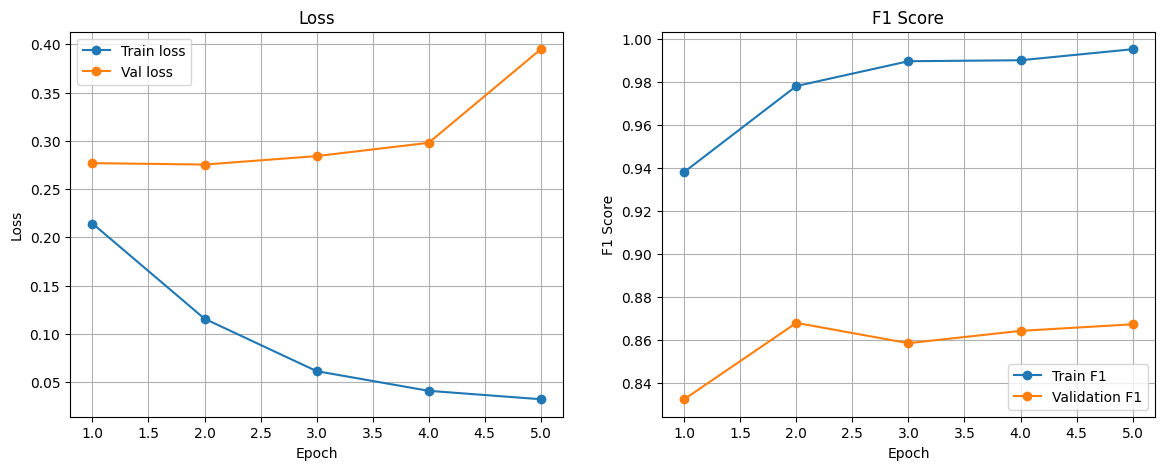

In [ ]:
trainer.plot_history()


Classification report:

              precision    recall  f1-score   support

      Normal       0.95      0.91      0.93      2444
       Toxic       0.83      0.91      0.87      1231

    accuracy                           0.91      3675
   macro avg       0.89      0.91      0.90      3675
weighted avg       0.91      0.91      0.91      3675



<Figure size 1200x1200 with 0 Axes>

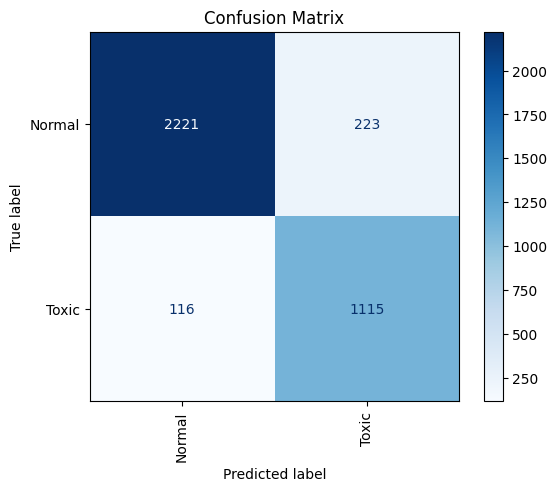

In [ ]:
trainer.classification_report()

In [ ]:
df = get_predict_text(model_bert, test_loader)
df['real'] = test_labels
df['correct'] = df['real'] == df['pred']
errors_data = df[df['correct'] == False].reset_index(drop=False)
sample_er = errors_data.sample(5, random_state = 42)
for i, row in sample_er.iterrows():
    true_label = "Токсичный" if row['real'] == 1 else "Нейтральный"
    pred_label = "Токсичный" if row['pred'] == 1 else "Нейтральный"
    confidence = row['probs'] if row['pred'] == 1 else 1 - row['probs']
    print(f'\nОшибка #{i+1}')
    print(f'Истина: {true_label} - Предсказано: {pred_label}')
    print(f'Уверенность модели: {confidence:.2%}')
    print(f'Текст:')
    print(f'{test_df.iloc[row["index"]]["text"]}')


Ошибка #26
Истина: Нейтральный - Предсказано: Токсичный
Уверенность модели: 94.63%
Текст:
добби свободен!!!!!!!!!!!!!!!!!!!! ох спасибо тебе добрая внученька!!!!!!!!!!!!!!!!!


Ошибка #310
Истина: Нейтральный - Предсказано: Токсичный
Уверенность модели: 99.91%
Текст:
Лепишь, творишь, малюееешь


Ошибка #74
Истина: Токсичный - Предсказано: Нейтральный
Уверенность модели: 94.21%
Текст:
афигеть баадер майнхоф, ещё 10 минут назад у меня в плеере играл альбом the gallery. и вижу этот пост.


Ошибка #196
Истина: Токсичный - Предсказано: Нейтральный
Уверенность модели: 92.83%
Текст:
Мать Серова была еврейкой по фамилии Бергман и у отца в крови были евреи, его дед был каким-то еврейским путешественником или исследователем, не помню.


Ошибка #58
Истина: Нейтральный - Предсказано: Токсичный
Уверенность модели: 99.06%
Текст:
Тебя возбуждает, когда жена переодевается в медсестру? Клизмует?



## cointegrated/rubert-tiny2

In [ ]:
model_name = "cointegrated/rubert-tiny2"

model_tiny = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
tokenizer = AutoTokenizer.from_pretrained(model_name)

train_loader, test_loader = creating_dataloader(tokenizer, batch_size = 16, max_len=256)
optimizer = torch.optim.AdamW(model_tiny.parameters(), lr=2e-5)

config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  118MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.74M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
trainer = Trainer(
    model=model_tiny,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=test_loader,
    device=device,
    scheduler=None,
    label_names=label_names,
    save_path="best_model_tiny.pt"
)

trainer.fit(epochs=8)


Epoch 1/8


Computing train F1: 100%|██████████| 631/631 [00:18<00:00, 34.75it/s]


Train loss: 0.3118 | Val loss: 0.2379 | Accuracy: 0.9072 | Train F1: 0.9018 | Val F1: 0.8613
Best model saved

Epoch 2/8


Computing train F1: 100%|██████████| 631/631 [00:11<00:00, 56.70it/s]


Train loss: 0.1915 | Val loss: 0.2286 | Accuracy: 0.9132 | Train F1: 0.9346 | Val F1: 0.8741
Best model saved

Epoch 3/8


...

Train loss: 0.1436 | Val loss: 0.2374 | Accuracy: 0.9159 | Train F1: 0.9570 | Val F1: 0.8726

Epoch 4/8


Computing train F1: 100%|██████████| 631/631 [00:11<00:00, 53.01it/s]


Train loss: 0.1047 | Val loss: 0.2541 | Accuracy: 0.9132 | Train F1: 0.9727 | Val F1: 0.8717

Epoch 5/8


Computing train F1: 100%|██████████| 631/631 [00:11<00:00, 52.90it/s]

Train loss: 0.0719 | Val loss: 0.2866 | Accuracy: 0.9143 | Train F1: 0.9827 | Val F1: 0.8724
Early stopping

Training finished


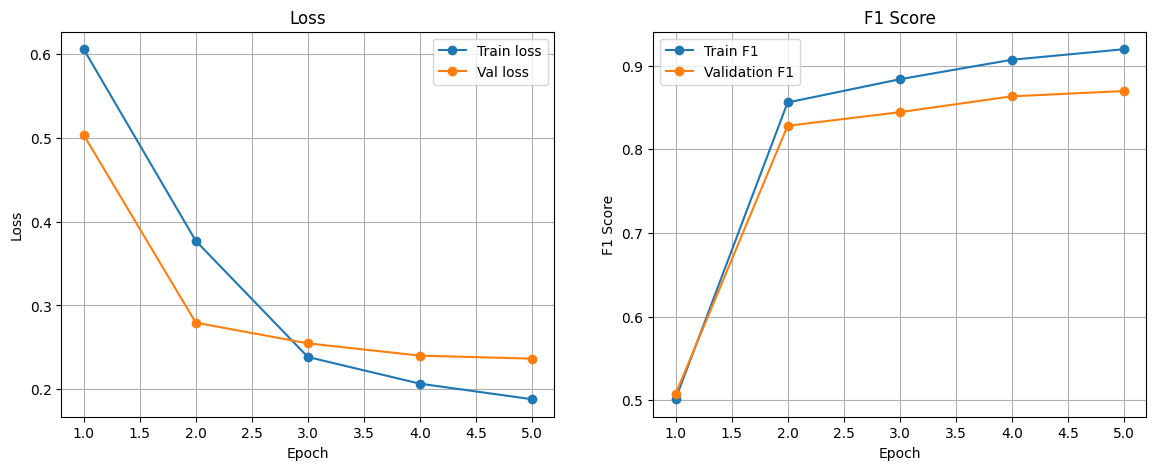

In [ ]:
trainer.plot_history()


Classification report:

              precision    recall  f1-score   support

      Normal       0.95      0.92      0.93      2444
       Toxic       0.85      0.90      0.87      1231

    accuracy                           0.91      3675
   macro avg       0.90      0.91      0.90      3675
weighted avg       0.92      0.91      0.91      3675



<Figure size 1200x1200 with 0 Axes>

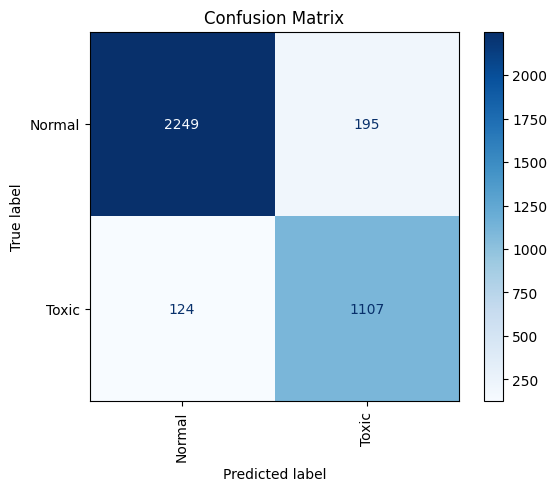

In [ ]:
trainer.classification_report()

In [ ]:
df_1 = get_predict_text(model_tiny, test_loader)
df_1['real'] = test_labels
df_1['correct'] = df_1['real'] == df_1['pred']
errors_data = df_1[df_1['correct'] == False].reset_index(drop=False)
sample_er = errors_data.sample(5, random_state = 42)
for i, row in sample_er.iterrows():
    true_label = "Токсичный" if row['real'] == 1 else "Нейтральный"
    pred_label = "Токсичный" if row['pred'] == 1 else "Нейтральный"
    confidence = row['probs'] if row['pred'] == 1 else 1 - row['probs']
    print(f'\nОшибка #{i+1}')
    print(f'Истина: {true_label} - Предсказано: {pred_label}')
    print(f'Уверенность модели: {confidence:.2%}')
    print(f'Текст:')
    print(f'{test_df.iloc[row["index"]]["text"]}')


Ошибка #74
Истина: Токсичный - Предсказано: Нейтральный
Уверенность модели: 80.82%
Текст:
Помню его пожалуй с 50 к подписоты, вроде как то так. Снимал простенько, без вебки, т.е ебалом не светил т было уже норм. Играл в простенькие игры, по типу майна. Самое последнее адекватное видео - было поздравительное на 300к подрисчиков, чем-то интересным чтоль веялом, тогда на тытубе не было подобных форматов аля скетчи-влоги, уже не вспомню ну, а дальше пошел полнейший тренд ец, светило ебалом, какие то скетчи со смехуечками естестна не смешными для дерградантов , кривляние. Вообщем, тащемта полная херня, а как увидел что на n-миллионов подрисчиков он устроил какой-то скучный стрим, то нахер отписался и дизу поставил.


Ошибка #219
Истина: Токсичный - Предсказано: Нейтральный
Уверенность модели: 95.61%
Текст:
Ну это типично. Как он вёл? -нормально же


Ошибка #26
Истина: Токсичный - Предсказано: Нейтральный
Уверенность модели: 96.20%
Текст:
Хотел тоже самое на оф форуме написать (только без у

## sberbank-ai/ruBert-base

In [ ]:
model_name = 'sberbank-ai/ruBert-base'

model_ruBert = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
tokenizer = AutoTokenizer.from_pretrained(model_name)

train_loader, test_loader = creating_dataloader(tokenizer, batch_size = 16, max_len=256)
optimizer = torch.optim.AdamW(model_ruBert.parameters(), lr=2e-5)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: sberbank-ai/ruBert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params w

In [ ]:
trainer = Trainer(
    model=model_ruBert,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=test_loader,
    device=device,
    scheduler=None,
    label_names=label_names,
    save_path="best_model_ruBert.pt"
)

trainer.fit(epochs=5)


Epoch 1/5


Computing train F1: 100%|██████████| 631/631 [00:38<00:00, 16.32it/s]


Train loss: 0.2307 | Val loss: 0.2075 | Accuracy: 0.9252 | Train F1: 0.9498 | Val F1: 0.8880
Best model saved

Epoch 2/5


Computing train F1: 100%|██████████| 631/631 [00:38<00:00, 16.36it/s]


Train loss: 0.1125 | Val loss: 0.2656 | Accuracy: 0.9135 | Train F1: 0.9813 | Val F1: 0.8632

Epoch 3/5


Computing train F1: 100%|██████████| 631/631 [00:38<00:00, 16.37it/s]


Train loss: 0.0530 | Val loss: 0.2914 | Accuracy: 0.9208 | Train F1: 0.9922 | Val F1: 0.8819

Epoch 4/5


Computing train F1: 100%|██████████| 631/631 [00:38<00:00, 16.36it/s]

Train loss: 0.0272 | Val loss: 0.3836 | Accuracy: 0.9107 | Train F1: 0.9959 | Val F1: 0.8580
Early stopping

Training finished


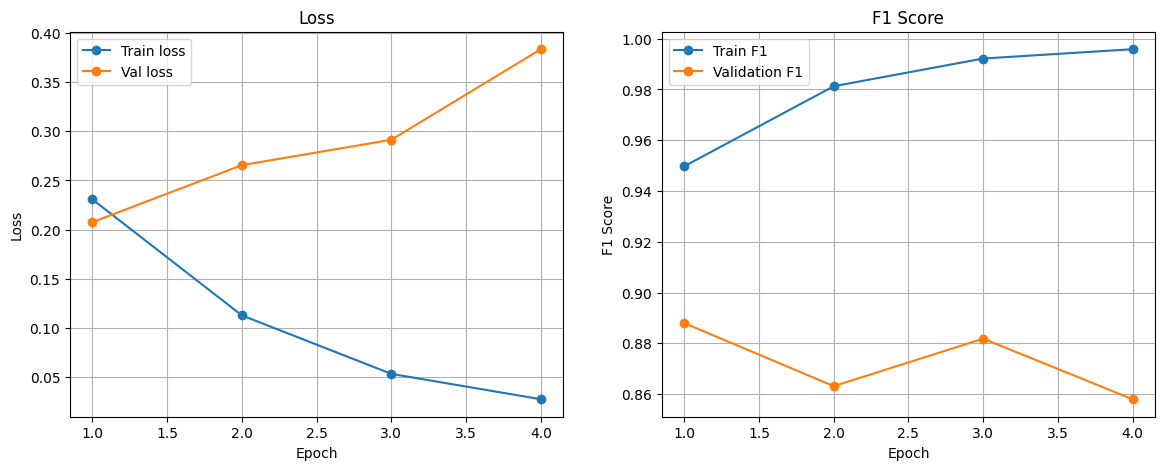

In [ ]:
trainer.plot_history()


Classification report:

              precision    recall  f1-score   support

      Normal       0.94      0.95      0.94      2444
       Toxic       0.89      0.89      0.89      1231

    accuracy                           0.93      3675
   macro avg       0.92      0.92      0.92      3675
weighted avg       0.93      0.93      0.93      3675



<Figure size 1200x1200 with 0 Axes>

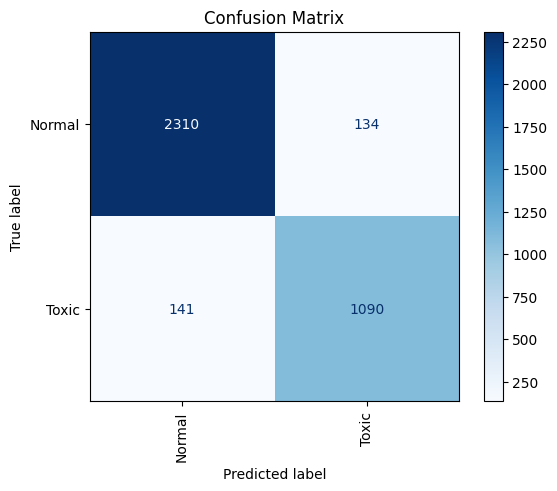

In [ ]:
trainer.classification_report()

In [ ]:
df = get_predict_text(model_ruBert, test_loader)
df['real'] = test_labels
df['correct'] = df['real'] == df['pred']
errors_data = df[df['correct'] == False].reset_index(drop=False)
sample_er = errors_data.sample(5, random_state = 42)
for i, row in sample_er.iterrows():
    true_label = "Токсичный" if row['real'] == 1 else "Нейтральный"
    pred_label = "Токсичный" if row['pred'] == 1 else "Нейтральный"
    confidence = row['probs'] if row['pred'] == 1 else 1 - row['probs']
    print(f'\nОшибка #{i+1}')
    print(f'Истина: {true_label} - Предсказано: {pred_label}')
    print(f'Уверенность модели: {confidence:.2%}')
    print(f'Текст:')
    print(f'{test_df.iloc[row["index"]]["text"]}')


Ошибка #232
Истина: Токсичный - Предсказано: Нейтральный
Уверенность модели: 90.15%
Текст:
Да, тяжелая штука. Важно помнить - ты в этой жизни ТАКАЯ. Ну вот такая.. Ну вот так вышло. Такой тебя папа с мамой сделали, как вышло, ничего не поделаеш. Вот и живи себе, старайся посильно. Если чего не получается - ну, в этот раз не получилось у нас есть еще одна спичка, еще один шанс . У тебя спичек коробок. А другие - такие же. С тарелок едят, в унитаз срут. Остальное - понты. Надо, надо пробовать! Хотябы для того, чтоб сказать - да, я пробовала, у меня не получилось. Но оно получится. Ты сильная, признайся себе в этом.


Ошибка #111
Истина: Токсичный - Предсказано: Нейтральный
Уверенность модели: 56.33%
Текст:
Червепидорские страны парашной конфедерации -Казахстан. Президент Нурсултан Назарбаев правит с 89 года (30 лет, рекорд) и до наших дней, совершив многоходвочку и передав власть от президента к своей новой должности Отца Нации. Превратил одну из самых перспективных стран региона в гула